# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif


In [2]:
## Makes Illustrator recognize text in saved PDF figures:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

## Frequency analysis

In [4]:
idata_frequency = az.from_netcdf(RESULTS_DIR / "idata_plasma_na_empa_minus_vehicle.nc")
idata_frequency_bsl = az.from_netcdf(RESULTS_DIR / "idata_plasma_na_vehicle.nc")
idata_frequency

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [5]:
print("Plasma Na change (empa - vehicle):")
display(az.summary(idata_frequency, var_names=["~mu", "~1|rat"]))
print("Plasma Na at baseline (vehicle):")
display(az.summary(idata_frequency_bsl, var_names=["~mu", "~1|rat"]))

Plasma Na change (empa - vehicle):


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,9.007,1.241,6.743,11.248,0.025,0.024,2489.0,2117.0,1.0
Intercept,5.002,3.198,-1.166,10.898,0.058,0.050,3006.0,3093.0,1.0
gtyp[fa/fa],9.486,4.817,0.096,18.277,0.095,0.088,2579.0,2450.0,1.0
age[Young],0.824,4.551,-7.612,9.475,0.091,0.078,2465.0,2586.0,1.0
sex[M],4.005,4.430,-4.282,12.314,0.088,0.076,2566.0,2477.0,1.0
"gtyp:age[fa/fa, Young]",-0.776,6.378,-13.613,10.596,0.135,0.111,2221.0,2436.0,1.0
"gtyp:sex[fa/fa, M]",-8.421,6.305,-19.622,3.654,0.129,0.112,2407.0,2369.0,1.0


Plasma Na at baseline (vehicle):


/Users/lampochka/Desktop/kidney_test/kidney/.venv/lib/python3.14/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['1|rat'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,4.687,0.018,4.650,4.717,0.000,0.000,3968.0,2844.0,1.0
gtyp[fa/fa],-0.063,0.047,-0.158,0.015,0.001,0.001,2332.0,2784.0,1.0
age[Young],0.005,0.025,-0.041,0.055,0.000,0.000,3619.0,2681.0,1.0
sex[M],-0.036,0.025,-0.085,0.010,0.000,0.001,3132.0,2584.0,1.0
"gtyp:age[fa/fa, Young]",-0.014,0.057,-0.118,0.094,0.001,0.001,3095.0,2996.0,1.0
"gtyp:sex[fa/fa, M]",0.087,0.060,-0.020,0.205,0.001,0.001,2547.0,2561.0,1.0
sigma_Intercept,-3.018,0.210,-3.392,-2.601,0.004,0.004,3116.0,2302.0,1.0
sigma_gtyp[fa/fa],0.771,0.274,0.267,1.282,0.004,0.005,3791.0,2699.0,1.0
sigma[0],0.050,0.011,0.032,0.071,0.000,0.000,3116.0,2302.0,1.0
sigma[1],0.050,0.011,0.032,0.071,0.000,0.000,3116.0,2302.0,1.0


## Compute and plot TS for all groups

In [6]:
t_groups_change, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_frequency, idata_frequency_bsl)
)

In [7]:
ts_change, ts_vehicle = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))

print("Vehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'fa/fa adult M': 0.9925,
 'fa/fa young M': 0.99425,
 'fa/+ adult M': 0.99,
 'fa/+ young M': 0.99325,
 'fa/fa adult F': 0.99975,
 'fa/fa young F': 0.99925,
 'fa/+ adult F': 0.94725,
 'fa/+ young F': 0.915}

Vehicle sign probabilities:


{'fa/fa adult M': 1.0,
 'fa/fa young M': 1.0,
 'fa/+ adult M': 1.0,
 'fa/+ young M': 1.0,
 'fa/fa adult F': 1.0,
 'fa/fa young F': 1.0,
 'fa/+ adult F': 1.0,
 'fa/+ young F': 1.0}

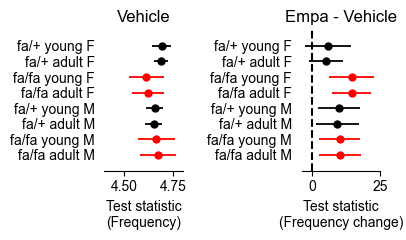

In [9]:
f, axes = plt.subplots(1, 2, figsize=(4, 2.5))
axes[1] = forestplot_oz(axes[1], ts_change);
axes[1].set_title("Empa - Vehicle");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('Test statistic\n(Frequency change)')
axes[0].set_xlabel('Test statistic\n(Frequency)')

axes[0].set_xlim(4.4,4.8)
axes[1].set_xlim(-4,25)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_PlasmaNa_groups.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between fa/fa and fa/+ genotypes

In [10]:
ts_change, ts_vehicle = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        "M": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2,
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],    
        "F": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2
        # "adult": (t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"] + t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"])/2,
        # "young": (t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"] + t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"])/2
       
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'M adult': 0.57825,
 'M young': 0.52925,
 'M': 0.57,
 'F adult': 0.973,
 'F young': 0.9265,
 'F': 0.979}


Vehicle sign probabilities:


{'M adult': 0.67975,
 'M young': 0.57625,
 'M': 0.65725,
 'F adult': 0.0805,
 'F young': 0.06625,
 'F': 0.0365}

[]

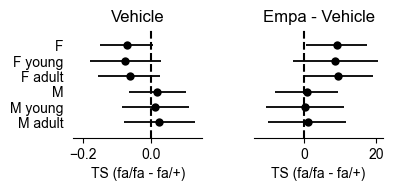

In [15]:
f, axes = plt.subplots(1, 2, figsize=(4, 1.4))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empa - Vehicle')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (fa/fa - fa/+)')


axes[0].set_xlim(-0.23, 0.15)
axes[1].set_xlim(-14, 22)

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_PlasmaNa_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between young and adult

In [17]:
ts_change, ts_vehicle = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "fa/fa": (t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"])/2,
        # "fa/+": (t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Change sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Change sign probabilities:


{'fa/fa': 0.505, 'fa/+': 0.57075}


Vehicle sign probabilities:


{'fa/fa': 0.42225, 'fa/+': 0.58175}

[]

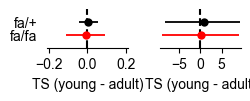

In [18]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
# axes[0].set_xlim(-1.6,1.9)
# axes[1].set_xlim(None, 4)

# axes[1].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[0].set_xticks([-0.01, 0, 0.01], [-0.01, 0, 0.01])

axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_PlasmaNa_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## Compute and plot TS representing the difference between males and females

In [19]:
ts_change, ts_vehicle = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_change, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'change':get_sign_probs(ts_change),
    'change_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_change).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_change))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa': 0.15525, 'fa/+': 0.82025}


Vehicle sign probabilities:


{'fa/fa': 0.83825, 'fa/+': 0.068}

[]

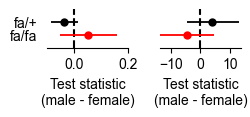

In [20]:
f, axes = plt.subplots(1, 2, figsize=(2.5, 0.5))
plt.subplots_adjust(wspace=0.4)

for ax, ts_, tle in zip(axes, (ts_vehicle, ts_change), ('Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(male - female)')
    
axes[0].set_xlim(-0.1,.2)
# axes[1].set_xlim(-.6, 1.8)
# axes[0].set_xticks([-0.005, 0, 0.005], [-0.005, 0, 0.005])
# axes[1].set_xticks([-0.01, 0], [-0.01, 0])
axes[1].set_yticks([],[])

# f.savefig(PLOT_DIR / "ts_PlasmaNa_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [21]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('plasmaNa',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/PlasmaNa.csv')
sp_all

change change_signif  vehicle vehicle_signif
contrast      group                                                       
plasmaNa      fa/fa adult M  0.99250             *      NaN            NaN
              fa/fa young M  0.99425             *      NaN            NaN
              fa/+ adult M   0.99000             *      NaN            NaN
              fa/+ young M   0.99325             *      NaN            NaN
              fa/fa adult F  0.99975             *      NaN            NaN
              fa/fa young F  0.99925             *      NaN            NaN
              fa/+ adult F   0.94725                    NaN            NaN
              fa/+ young F   0.91500                    NaN            NaN
fa/fa - fa/+  M adult        0.57825                0.67975               
              M young        0.52925                0.57625               
              M              0.57000                0.65725               
              F adult        0.97300                0.08050               
              F young        0.92650                0.06625               
              F              0.97900             *  0.03650               
young - adult fa/fa          0.50500                0.42225               
              fa/+           0.57075                0.58175               
male - female fa/fa          0.15525                0.83825               
              fa/+           0.82025                0.06800